In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/output/regression_predictions.csv")

df.head()

,timestamp,real_CO,predicted_CO
0,2005-01-29 07:00:00,-1.137277,-1.066401
1,2005-01-29 08:00:00,-0.930843,-0.897126
2,2005-01-29 09:00:00,-0.724409,-0.896437
3,2005-01-29 10:00:00,-0.724409,-0.842765
4,2005-01-29 11:00:00,-0.724409,-0.778082


In [3]:
print("Dimensiones del dataset:", df.shape)

df.describe()

Dimensiones del dataset: (1535, 3)


,real_CO,predicted_CO
count,1535.000000,1535.000000
mean,-0.103629,-0.159393
std,0.925480,0.840419
min,-1.412521,-1.275587
25%,-0.793221,-0.757439
50%,-0.380354,-0.416823
75%,0.307758,0.212455
max,4.298807,3.731115


In [4]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

y_true = df["real_CO"]
y_pred = df["predicted_CO"]

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

MAE : 0.2651
RMSE: 0.3871
R2  : 0.8249


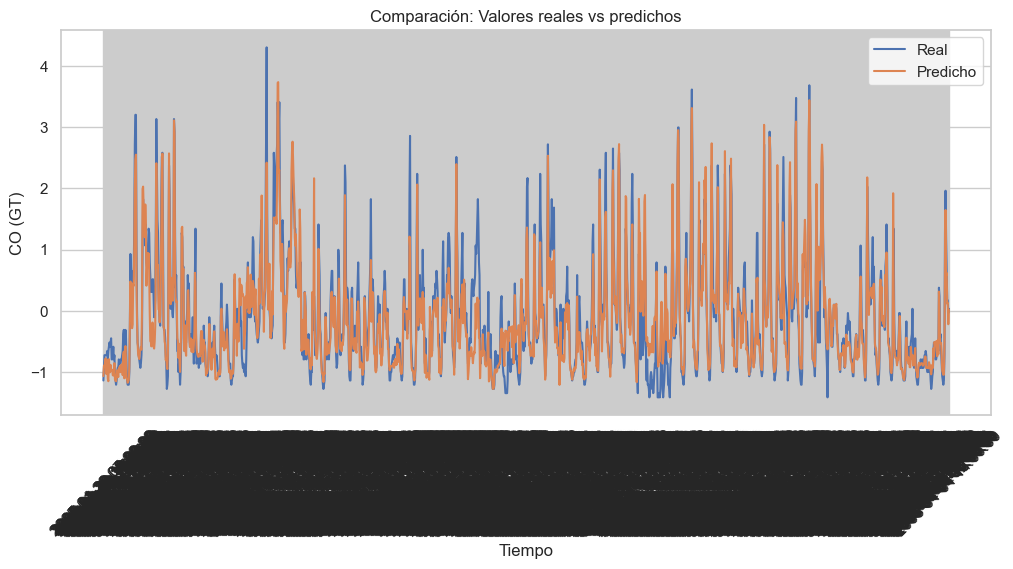

In [5]:
plt.figure(figsize=(12,5))

sns.lineplot(x=df["timestamp"], y=df["real_CO"], label="Real")
sns.lineplot(x=df["timestamp"], y=df["predicted_CO"], label="Predicho")

plt.xticks(rotation=45)
plt.title("Comparación: Valores reales vs predichos")
plt.xlabel("Tiempo")
plt.ylabel("CO (GT)")
plt.legend()

plt.show()

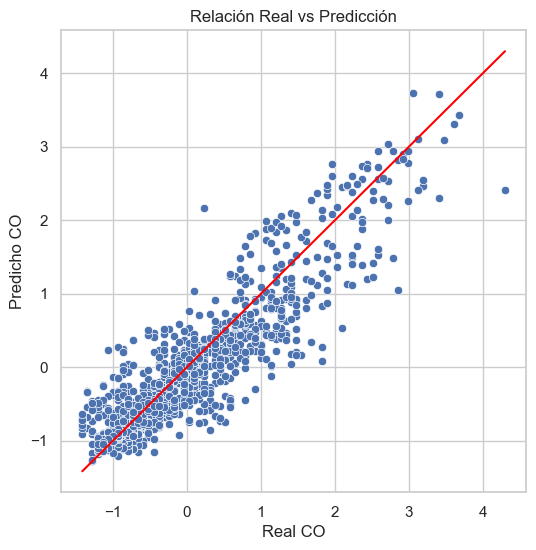

In [6]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_true, y=y_pred)

plt.xlabel("Real CO")
plt.ylabel("Predicho CO")
plt.title("Relación Real vs Predicción")

# Línea ideal
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color="red")

plt.show()

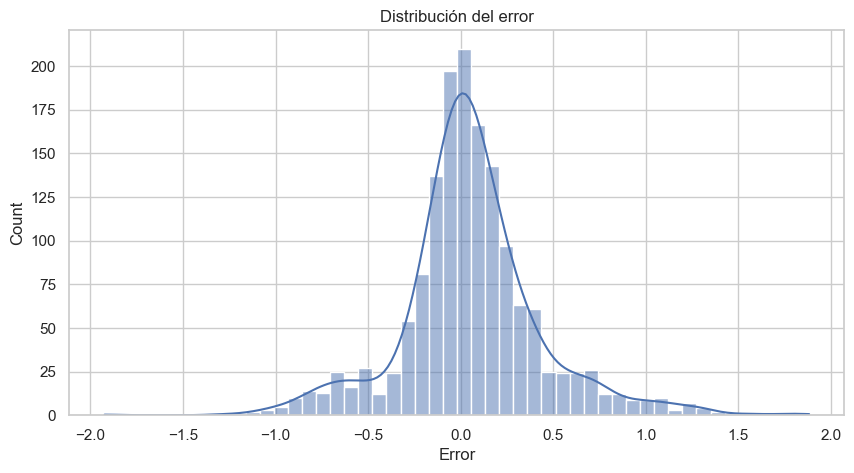

In [7]:
df["error"] = df["real_CO"] - df["predicted_CO"]

plt.figure(figsize=(10,5))
sns.histplot(df["error"], bins=50, kde=True)

plt.title("Distribución del error")
plt.xlabel("Error")

plt.show()

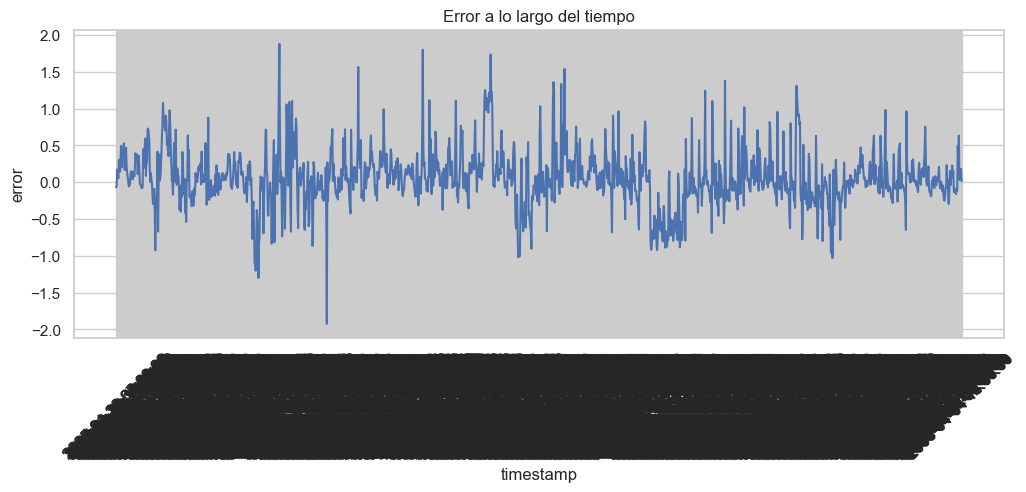

In [8]:
plt.figure(figsize=(12,4))

sns.lineplot(x=df["timestamp"], y=df["error"])

plt.xticks(rotation=45)
plt.title("Error a lo largo del tiempo")

plt.show()

In [9]:
print("Interpretación del modelo:")

if r2 > 0.8:
    print("Modelo muy bueno")
elif r2 > 0.5:
    print("Modelo aceptable")
else:
    print("Modelo mejorable")

print("\nErrores medios:", mae)

Interpretación del modelo:
Modelo muy bueno

Errores medios: 0.26509196859196127
